In [50]:
import os
import re

def parse_line(line):
    # Парсит строку 'P:1 Nt:100 Time:1787.11ms' в [1, 100, 1787.11]
    pattern = r"P:(\d+)\s+Nt:(\d+)\s+Time:([\d.]+)ms"
    match = re.match(pattern, line.strip())
    if match:
        return [int(match.group(1)), int(match.group(2)), float(match.group(3))]
    return None

def process_directory(directory_path):
    all_points = []
    for filename in os.listdir(directory_path):
        file_path = os.path.join(directory_path, filename)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as file:
                for line in file:
                    parsed = parse_line(line)
                    if parsed:
                        all_points.append(parsed)
    return all_points

directory_path = "./results"  # Замени на путь к папке
result_array = process_directory(directory_path)
print(f"Всего точек: {len(result_array)}")
print("Первые 5 точек:", result_array[:5])

Всего точек: 700
Первые 5 точек: [[1, 100, 1787.11], [1, 200, 3528.97], [1, 300, 5297.24], [1, 400, 7053.3], [1, 500, 8773.88]]


In [51]:
import numpy as np
from scipy import stats
from collections import defaultdict

# 1. Группировка точек по (P, Nt)
groups = defaultdict(list)
for point in result_array:
    key = (point[0], point[1])  # Первые две координаты как ключ
    groups[key].append(point[2])  # Третья координата (Time) в список

# 2. Создание нового массива: [P, Nt, mean_Time, sem_Time]
result_array_awg = []
for (p, nt), times in groups.items():
    times_array = np.array(times)
    mean = np.mean(times_array)
    sem = stats.sem(times_array)  # Стандартная погрешность среднего
    result_array_awg.append([p, nt, mean, sem])

result_array_awg = np.array(result_array_awg)
print("Результат 5 первых точек:")
print(result_array_awg[:5])

Результат 5 первых точек:
[[1.00000000e+00 1.00000000e+02 1.79585429e+03 3.47992054e+00]
 [1.00000000e+00 2.00000000e+02 3.53824143e+03 2.45232973e+00]
 [1.00000000e+00 3.00000000e+02 5.30633429e+03 2.68800940e+00]
 [1.00000000e+00 4.00000000e+02 7.05865286e+03 6.39221987e+00]
 [1.00000000e+00 5.00000000e+02 8.78366571e+03 4.59594016e+00]]


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Создаем словарь для быстрого доступа к t(p=1,N_t)
p1_dict = {y: z for x, y, z, dz in result_array_awg if x == 1}

S = np.empty_like(result_array_awg)
E = np.empty_like(result_array_awg)

for i, (x, y, z, dz) in enumerate(result_array_awg):
    f1y = p1_dict[y]
    
    # Вычисляем S(x,y) = f(1,y)/f(x,y)
    S_val = f1y / z
    S_dz = S_val * np.sqrt((dz/z)**2 + (p1_dict.get((1,y), (0,0))[1]/f1y)**2) if f1y != 0 else 0
    
    # Заполняем массив S
    S[i, 0] = x
    S[i, 1] = y
    S[i, 2] = S_val
    S[i, 3] = S_dz
    
    # Вычисляем E(x,y) = S(x,y)/x
    E_val = S_val / x
    E_dz = S_dz / x
    
    # Заполняем массив E
    E[i, 0] = x
    E[i, 1] = y
    E[i, 2] = E_val
    E[i, 3] = E_dz

# Разделение данных
p = result_array_awg[:, 0]
N_t = result_array_awg[:, 1]
t_awg = result_array_awg[:, 2]
dt = result_array_awg[:, 3]


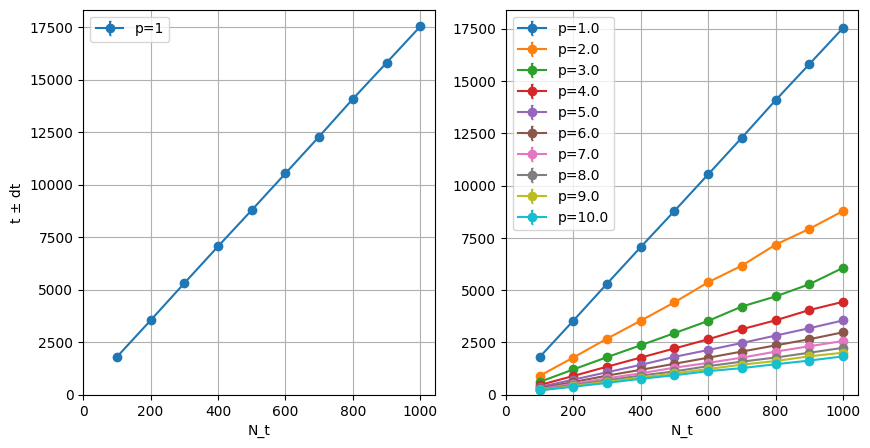

In [73]:
fig = plt.figure(figsize=(10, 5))
a1 = fig.add_subplot(121)

fixed_p = 1 # Задайте нужное значение
mask = (p == fixed_p)
a1.errorbar(N_t[mask], t_awg[mask], yerr=dt[mask], fmt='o-', capsize=1, label=f'p={fixed_p}')

plt.xlabel('N_t')
plt.ylabel('t ± dt')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.ylim(bottom=0)  # Начинаем ось Y с 0
plt.legend()

# ALL IN ONE
a2 = fig.add_subplot(122)
unique_p = np.unique(p)
for fixed_p in unique_p:
    mask = (p == fixed_p)
    a2.errorbar(N_t[mask], t_awg[mask], yerr=dt[mask], fmt='o-',capsize=1, label=f'p={fixed_p}')

plt.xlabel('N_t')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.ylim(bottom=0)  # Начинаем ось Y с 0
plt.legend()
plt.show()

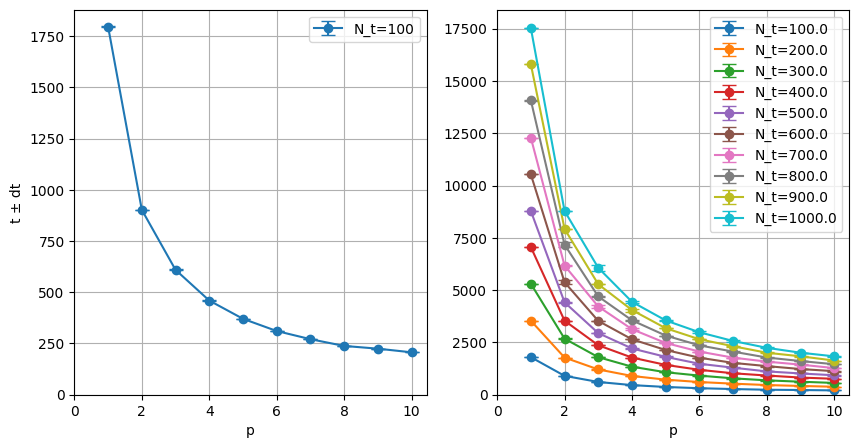

In [57]:
fig = plt.figure(figsize=(10, 5))
a1 = fig.add_subplot(121)

fixed_N_t = 100  # Задайте нужное значение
mask = (N_t == fixed_N_t)

a1.errorbar(p[mask], t_awg[mask], yerr=dt[mask], fmt='o-', capsize=5, label=f'N_t={fixed_N_t}')
plt.xlabel('p')
plt.ylabel('t ± dt')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.ylim(bottom=0)  # Начинаем ось Y с 0
plt.legend()

# ALL IN ONE
a2 = fig.add_subplot(122)
unique_N_t = np.unique(N_t)
for fixed_N_t in unique_N_t:
    mask = (N_t == fixed_N_t)
    a2.errorbar(p[mask], t_awg[mask], yerr=dt[mask], fmt='o-', capsize=5, label=f'N_t={fixed_N_t}')

plt.xlabel('p')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.ylim(bottom=0)  # Начинаем ось Y с 0
plt.legend()
plt.show()

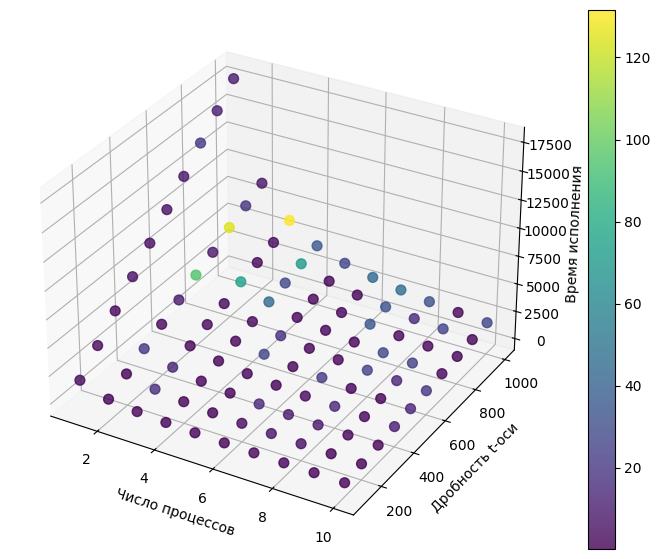

In [55]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(p, N_t, t_awg, c=dt, cmap='viridis', s=50, alpha=0.8)

# Добавляем цветовую шкалу для dz
cbar = fig.colorbar(sc)
ax.set_xlabel('Число процессов')
ax.set_ylabel('Дробность t-оси')
ax.set_zlabel('Время исполнения')
plt.show()

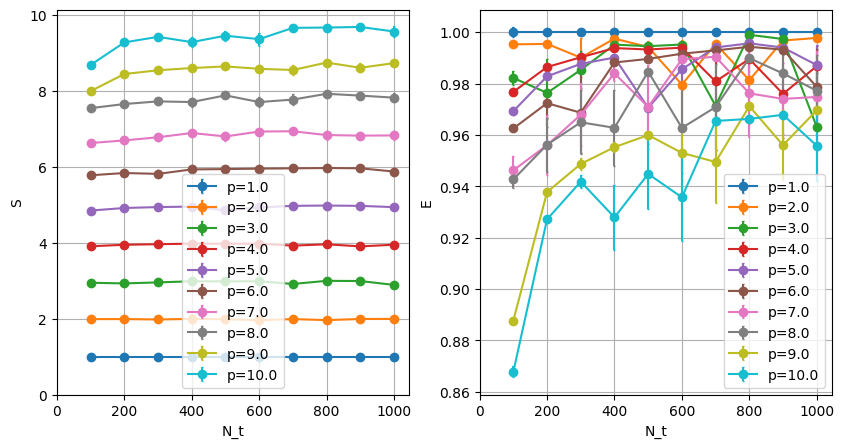

In [78]:
fig = plt.figure(figsize=(10, 5))

a1 = fig.add_subplot(121)
t_awg = S[:, 2]
dt = S[:, 3]

unique_p = np.unique(p)
for fixed_p in unique_p:
    mask = (p == fixed_p)
    a1.errorbar(N_t[mask], t_awg[mask], yerr=dt[mask], fmt='o-',capsize=1, label=f'p={fixed_p}')

plt.xlabel('N_t')
plt.ylabel('S')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.ylim(bottom=0)  # Начинаем ось Y с 0
plt.legend()

a2 = fig.add_subplot(122)
t_awg = E[:, 2]
dt = E[:, 3]

unique_p = np.unique(p)
for fixed_p in unique_p:
    mask = (p == fixed_p)
    a2.errorbar(N_t[mask], t_awg[mask], yerr=dt[mask], fmt='o-',capsize=1, label=f'p={fixed_p}')

plt.xlabel('N_t')
plt.ylabel('E')
plt.grid(True)
plt.xlim(left=0)  # Начинаем ось X с 0
plt.legend()
plt.show()

# Теоретическая база по параллельным вычислениям

## 1. Ускорение и эффективность параллельных алгоритмов
- **Ускорение (Speedup, $S_p$)**  
  $$ S_p = \frac{T_1}{T_p} $$  
  где $T_1$ — время на 1 процессоре, $T_p$ — на $p$ процессорах.
- **Эффективность ($E_p$)**  
  $$ E_p = \frac{S_p}{p} \times 100\% $$
- Идеальное ускорение: $S_p = p$ (линейное).
- Ограничения: накладные расходы, дисбаланс загрузки.

---

## 2. Закон Амдаля
$$ S_{\text{max}} = \frac{1}{(1 - P) + \frac{P}{N}} $$
- $P$ — доля параллелизуемой части.
- При $N \to \infty$: $S_{\text{max}} \leq \frac{1}{1-P}$.

---

## 3. Свойства канала передачи данных
- **Пропускная способность**: бит/с (макс. объем данных).
- **Латентность**: задержка передачи первого бита.
- **Факторы**: длина канала, маршрутизация, протоколы.

---

## 4. Обмены «точка-точка»
| Тип          | Характеристики                          | Примеры в MPI          |
|--------------|-----------------------------------------|------------------------|
| **Синхронный** | Блокирующий, требует координации       | `MPI_Send`, `MPI_Recv` |
| **Асинхронный**| Неблокирующий, перекрытие вычислений    | `MPI_Isend`            |
| **Буферизация**| Скрывает задержки, требует памяти      | Буферы MPI             |

---

## 5. Балансировка загрузки
```python
# Псевдокод для динамической балансировки
while tasks_left():
    process = get_least_loaded_worker()
    send_task(process, next_task())
```

- **Статическая**: предварительное распределение (матричные блоки).
- **Динамическая**: распределение "на лету" (пул задач).

---

## 6. Геометрический параллелизм
```mermaid
graph LR
    A[Исходная сетка] --> B(Декомпозиция)
    B --> C[Процессор 1: блок 1]
    B --> D[Процессор 2: блок 2]
```

- **Методы**: 1D/2D/3D декомпозиция.
- **Проблемы**: обмен граничными данными (halo-области).

---

## 7. Конвейерный параллелизм
```plaintext
Этап 1 → Этап 2 → Этап 3
   ↓       ↓       ↓
 CPU1    CPU2    CPU3
```
- **Оптимизация**: балансировка времени этапов.
- **Пример**: конвейер обработки изображений.